# vbOCP — Test 1: pipeline completa

Notebook orchestratore bash-style: le celle di codice lanciano solo comandi verso gli script della repo — nessuna logica del modello qui dentro. Stesso pattern per Colab/cluster: cambia solo dove lo lanci.

**Contenuto:**
1. Setup (path della repo)
2. FOM — solve singolo + plot, generazione snapshot
3. ROM (POD) — training + plot decadimento autovalori
4. GNN *(da aggiungere)*
5. Autoencoder *(da aggiungere)*

## 1. Setup

In [1]:
import os

# si sposta nella root della repo (dove c'e' src/), indipendentemente da dove parte il kernel
while not os.path.isdir('src') and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir('..')
assert os.path.isdir('src'), "src/ non trovata: verifica dove e' montata la repo vbOCP"

REPO_ROOT      = os.getcwd()
CONFIG_PATH    = os.path.join('configs', 'test1.yaml')
DATA_DIR       = os.path.join('data')
SNAPSHOTS_DIR  = os.path.join('data', 'snapshots')
OUTPUT_DIR     = os.path.join('notebooks', 'output')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SNAPSHOTS_DIR, exist_ok=True)

print('REPO_ROOT    :', REPO_ROOT)
print('CONFIG_PATH  :', CONFIG_PATH)
print('SNAPSHOTS_DIR:', SNAPSHOTS_DIR)

REPO_ROOT    : /shared/vbOCP
CONFIG_PATH  : configs/test1.yaml
SNAPSHOTS_DIR: data/snapshots


## 2. FOM

### 2.1 Solve singolo + plot

Risolve il FOM per una terna di parametri e salva un confronto visivo di stato `y` e aggiunto `p`. Modifica `--mu1`/`--mu2`/`--mu_u` per esplorare altri punti dello spazio parametrico.

In [ ]:
!python -m src.full_order.run_single_solve \
    --config {CONFIG_PATH} \
    --mu1 12 \
    --mu2 2.5 \
    --mu_u 0.99 \
    --plot

import tempfile, os as _os
from IPython.display import Image
Image(_os.path.join(tempfile.gettempdir(), 'fom_solution.png'))

### 2.2 Generazione snapshot (training + test)

Campiona `mu1`, `mu2`, `mu_u` uniformemente sui range definiti nel config e risolve il FOM per ciascun campione. L'assembly indipendente da mu viene fatto una sola volta; il ciclo aggiorna solo la matrice di controllo e il solve.

Due set separati (seed diversi): uno di **training** (per la POD) e uno di **test** (mai visto durante la POD, per validare il ROM). Se un file esiste gia', **non viene rigenerato** (skip).

Output: un `.npz` per set, con `mu1`, `mu2`, `mu_u`, e le matrici `Y`, `P`, `U` (una colonna per campione).

In [ ]:
N_SAMPLES = 300
N_TEST = 150
TEST_SEED = 123  # diverso dal seed di default usato per il training (42)

SNAPSHOTS_PATH = os.path.join(SNAPSHOTS_DIR, f'test1_{N_SAMPLES}.npz')
TEST_SNAPSHOTS_PATH = os.path.join(SNAPSHOTS_DIR, f'test1_test{N_TEST}.npz')

if os.path.exists(SNAPSHOTS_PATH):
    print(f"Training set gia' presente: {SNAPSHOTS_PATH} (skip)")
else:
    !python -m src.full_order.generate_snapshots \
        --config {CONFIG_PATH} \
        --n-samples {N_SAMPLES} \
        --output {SNAPSHOTS_PATH}

if os.path.exists(TEST_SNAPSHOTS_PATH):
    print(f"Test set gia' presente: {TEST_SNAPSHOTS_PATH} (skip)")
else:
    !python -m src.full_order.generate_snapshots \
        --config {CONFIG_PATH} \
        --n-samples {N_TEST} \
        --seed {TEST_SEED} \
        --output {TEST_SNAPSHOTS_PATH}

In [ ]:
import numpy as np

data = np.load(SNAPSHOTS_PATH)
print('Training - chiavi:', list(data.keys()), ' Y shape:', data['Y'].shape)

test_data = np.load(TEST_SNAPSHOTS_PATH)
print('Test     - chiavi:', list(test_data.keys()), ' Y shape:', test_data['Y'].shape)

## 3. ROM (POD)

Costruisce la base POD per stato e aggiunto a partire dagli snapshot generati sopra. Il numero di modi N e' scelto automaticamente in base a una soglia di energia cumulata (non piu' fisso). Prodotto scalare configurabile qui sotto; `--plot` mostra subito il decadimento degli autovalori (nessun path da gestire).

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Prodotto scalare: seminorm
Caricamento snapshot da data/snapshots/test1_300.npz ...
Y shape: (5306, 300), P shape: (5306, 300)
N scelto: stato=71, aggiunto=19 -> uso N=71 per entrambi
Base POD salvata in data/snapshots/test1_pod.npz
Plot salvato in /tmp/pod_eigenvalue_decay.png
PLOT_PATH=/tmp/pod_eigenvalue_decay.png


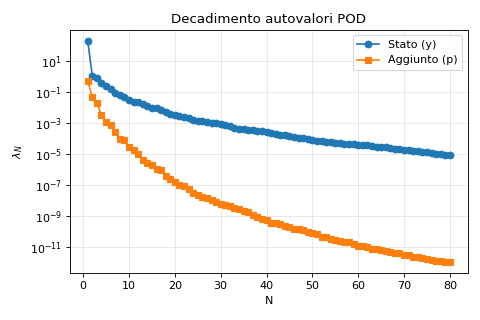

In [8]:
INNER_PRODUCT = 'seminorm'  # 'seminorm' (solo A_diff) o 'full' (A_diff + M_full)
ENERGY_THRESHOLD = 1-1e-6   # N scelto automaticamente in base a questa soglia
POD_PATH = os.path.join(SNAPSHOTS_DIR, 'test1_pod.npz')

!python -m src.rom.train_pod \
    --config {CONFIG_PATH} \
    --snapshots {SNAPSHOTS_PATH} \
    --inner-product {INNER_PRODUCT} \
    --energy-threshold {ENERGY_THRESHOLD} \
    --output {POD_PATH} \
    --plot

import tempfile, os as _os
from IPython.display import Image
Image(_os.path.join(tempfile.gettempdir(), 'pod_eigenvalue_decay.png'))

## 4. GNN

*(da aggiungere)*

## 5. Autoencoder

*(da aggiungere)*